In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("messy_ecommerce_sales_data.csv")

In [3]:

df.head()

,ID,Customer_Name,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total
0,100,Customer_100,ORD-41285,11/22/2024,Blender,Home,3,38,Cash on Delivery,Shipped,114.00
1,101,Customer_101,ORD-35783,7/5/2025,Smartphone,Electronics,2,abd,PayPal,Processing,NaN
2,102,Customer_102,ORD-84355,12/23/2024,Tennis Racket,Sports,1,389.05,PayPal,Delivered,389.05
3,103,Customer_103,ORD-57811,3/19/2025,Science,Books,5,233.92,PayPal,Processing,1169.60
4,104,Customer_104,ORD-93614,10/20/2025,Biography,Books,1,552.51,Cash on Delivery,Processing,552.51


In [4]:
df.shape

(103, 11)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 103 entries, 0 to 102
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID              103 non-null    int64  
 1    Customer_Name  103 non-null    str    
 2   Order_ID        103 non-null    str    
 3   Order_Date      103 non-null    str    
 4   Product         103 non-null    str    
 5    Category       95 non-null     str    
 6   Quantity        98 non-null     str    
 7   Price           98 non-null     str    
 8   Payment_Method  103 non-null    str    
 9   Status          103 non-null    str    
 10  Total           89 non-null     float64
dtypes: float64(1), int64(1), str(9)
memory usage: 9.0 KB


In [6]:
df.describe()

,ID,Total
count,103.000000,89.000000
mean,149.640777,1232.949101
std,28.704326,2605.471455
min,100.000000,-20000.000000
25%,125.500000,582.130000
50%,149.000000,1138.760000
75%,174.500000,2153.400000
max,199.000000,4722.700000


In [7]:
df.isnull().sum()

ID                 0
 Customer_Name     0
Order_ID           0
Order_Date         0
Product            0
 Category          8
Quantity           5
Price              5
Payment_Method     0
Status             0
Total             14
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(1)

In [9]:
df.dtypes

ID                  int64
 Customer_Name        str
Order_ID              str
Order_Date            str
Product               str
 Category             str
Quantity              str
Price                 str
Payment_Method        str
Status                str
Total             float64
dtype: object

In [10]:
for col in df.columns:
    print(col)
    print(df[col].unique())
    print("----------------")

ID
[100 101 102 103 104 105 106 107 108 109 110 111 112 113 114 115 116 117
 118 119 120 121 122 123 124 125 126 127 128 129 130 131 132 133 134 135
 136 137 138 139 140 141 142 143 144 145 146 147 148 149 150 151 152 153
 154 155 156 157 158 159 160 161 162 163 164 165 166 167 168 169 170 171
 172 173 174 175 176 177 178 179 180 181 182 183 184 185 186 187 188 189
 190 191 192 193 194 195 196 197 198 199]
----------------
 Customer_Name
<StringArray>
['Customer_100', 'Customer_101', 'Customer_102', 'Customer_103',
 'Customer_104', 'Customer_105', 'Customer_106', 'Customer_107',
 'Customer_108', 'Customer_109', 'Customer_110', 'Customer_111',
 'Customer_112', 'Customer_113', 'Customer_114', 'Customer_115',
 'Customer_116', 'Customer_117', 'Customer_118', 'Customer_119',
 'Customer_120', 'Customer_121', 'Customer_122', 'Customer_123',
 'Customer_124', 'Customer_125', 'Customer_126', 'Customer_127',
 'Customer_128', 'Customer_129', 'Customer_130', 'Customer_131',
 'Customer_132', 'Custom

In [11]:
df.describe()

,ID,Total
count,103.000000,89.000000
mean,149.640777,1232.949101
std,28.704326,2605.471455
min,100.000000,-20000.000000
25%,125.500000,582.130000
50%,149.000000,1138.760000
75%,174.500000,2153.400000
max,199.000000,4722.700000


# Data Quality Report

The dataset was inspected for:

- Missing values
- Duplicate rows
- Incorrect data types
- Inconsistent categorical values
- Numeric range anomalies

These issues will be cleaned in the following steps.

In [12]:
df.isnull().sum()

ID                 0
 Customer_Name     0
Order_ID           0
Order_Date         0
Product            0
 Category          8
Quantity           5
Price              5
Payment_Method     0
Status             0
Total             14
dtype: int64

In [13]:
df[" Category"] = df[" Category"].fillna(df[" Category"].mode()[0])

In [14]:
df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce")

df["Quantity"] = df["Quantity"].fillna(df["Quantity"].median())

In [15]:
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

df["Price"] = df["Price"].fillna(df["Price"].median())

In [16]:
df["Total"] = df["Total"].fillna(df["Quantity"] * df["Price"])

In [17]:
df.isnull().sum()

ID                0
 Customer_Name    0
Order_ID          0
Order_Date        0
Product           0
 Category         0
Quantity          0
Price             0
Payment_Method    0
Status            0
Total             0
dtype: int64

# Missing Value Handling

The dataset contained missing values in Category, Quantity, Price, and Total.

Cleaning decisions:
- Category: Missing values were filled using the mode because it is a categorical feature.
- Quantity: Converted to numeric and missing values were filled using the median to reduce the effect of outliers.
- Price: Converted to numeric and missing values were filled using the median.
- Total: Missing values were calculated as Quantity × Price since Total represents the product of these two columns.

After cleaning, no missing values remained in the dataset.

In [18]:
df.duplicated().sum()

np.int64(1)

In [19]:
before_rows = df.shape[0]

df = df.drop_duplicates()

after_rows = df.shape[0]

In [20]:
df.duplicated().sum()

np.int64(0)

In [21]:
print("Rows before removing duplicates:", before_rows)
print("Rows after removing duplicates:", after_rows)
print("Duplicate rows removed:", before_rows - after_rows)

Rows before removing duplicates: 103
Rows after removing duplicates: 102
Duplicate rows removed: 1


# Duplicate Removal

The dataset was checked for duplicate records using `df.duplicated().sum()`.

- Duplicate rows found: 1
- Duplicate rows removed: 1

After removing duplicates, the dataset contains only unique records.

In [22]:
df.columns = df.columns.str.strip()

In [23]:
df.columns

Index(['ID', 'Customer_Name', 'Order_ID', 'Order_Date', 'Product', 'Category',
       'Quantity', 'Price', 'Payment_Method', 'Status', 'Total'],
      dtype='str')

In [24]:
text_columns = df.select_dtypes(include="object").columns

for col in text_columns:
    df[col] = df[col].str.strip()

C:\Users\simra\AppData\Local\Temp\ipykernel_13928\3659800821.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_columns = df.select_dtypes(include="object").columns


In [25]:
df["Category"].unique()

<StringArray>
[       'Home', 'Electronics',      'Sports',       'Books',      'sports',
    'Clothing',  'electronic', 'ELECTRONICS', 'electronics']
Length: 9, dtype: str

In [26]:
df["Category"] = df["Category"].str.title()

In [27]:
df["Payment_Method"].unique()

<StringArray>
['Cash on Delivery', 'PayPal', 'Bank Transfer', 'Credit Card']
Length: 4, dtype: str

In [28]:
df["Payment_Method"] = df["Payment_Method"].str.title()

In [29]:
df["Status"].unique()

<StringArray>
['Shipped', 'Processing', 'Delivered', 'Cancelled', 'Returned']
Length: 5, dtype: str

In [30]:
df["Status"] = df["Status"].str.title()

In [31]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"], errors="coerce")

In [32]:
df["Order_Date"].head()

0   2024-11-22
1   2025-07-05
2   2024-12-23
3   2025-03-19
4   2025-10-20
Name: Order_Date, dtype: datetime64[us]

In [33]:
df["Order_Date"].dtype

dtype('<M8[us]')

In [34]:
df.head()

,ID,Customer_Name,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total
0,100,Customer_100,ORD-41285,2024-11-22,Blender,Home,3.0,38.000,Cash On Delivery,Shipped,114.00
1,101,Customer_101,ORD-35783,2025-07-05,Smartphone,Electronics,2.0,542.195,Paypal,Processing,1084.39
2,102,Customer_102,ORD-84355,2024-12-23,Tennis Racket,Sports,1.0,389.050,Paypal,Delivered,389.05
3,103,Customer_103,ORD-57811,2025-03-19,Science,Books,5.0,233.920,Paypal,Processing,1169.60
4,104,Customer_104,ORD-93614,2025-10-20,Biography,Books,1.0,552.510,Cash On Delivery,Processing,552.51


In [35]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 102 entries, 0 to 101
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   ID              102 non-null    int64         
 1   Customer_Name   102 non-null    str           
 2   Order_ID        102 non-null    str           
 3   Order_Date      100 non-null    datetime64[us]
 4   Product         102 non-null    str           
 5   Category        102 non-null    str           
 6   Quantity        102 non-null    float64       
 7   Price           102 non-null    float64       
 8   Payment_Method  102 non-null    str           
 9   Status          102 non-null    str           
 10  Total           102 non-null    float64       
dtypes: datetime64[us](1), float64(3), int64(1), str(6)
memory usage: 8.9 KB


# Standardization

The dataset contained inconsistent formatting in text columns and date values.

The following standardization steps were performed:

- Removed leading and trailing spaces from column names.
- Removed extra spaces from text values.
- Standardized Category, Payment_Method, and Status using title case.
- Converted Order_Date from text format to datetime.

These steps ensure consistency and improve data quality for analysis.

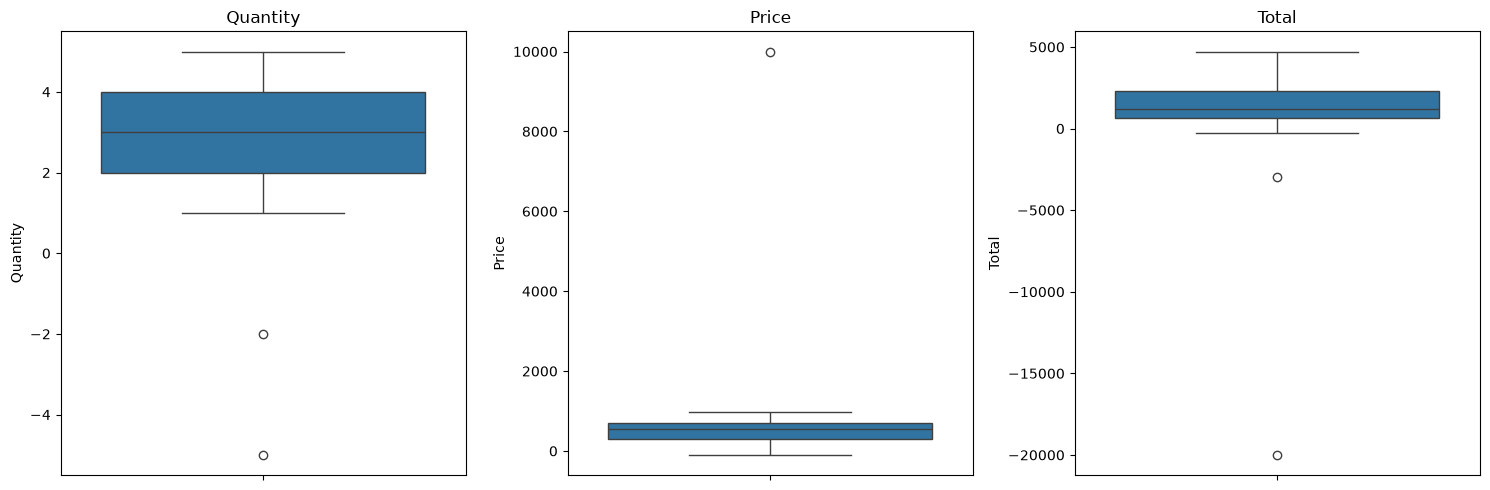

In [36]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
sns.boxplot(y=df["Quantity"])
plt.title("Quantity")

plt.subplot(1,3,2)
sns.boxplot(y=df["Price"])
plt.title("Price")

plt.subplot(1,3,3)
sns.boxplot(y=df["Total"])
plt.title("Total")

plt.tight_layout()
plt.show()

In [37]:
numeric_cols = ["Quantity", "Price", "Total"]

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

Quantity: 2 outliers
Price: 1 outliers
Total: 2 outliers


In [38]:
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])

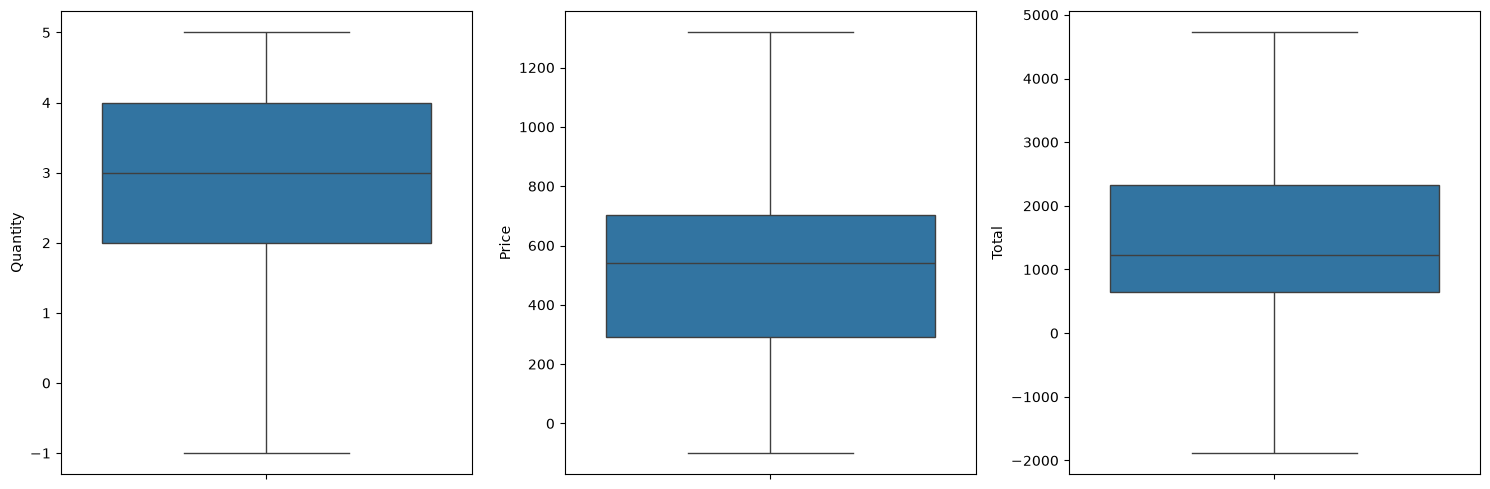

In [39]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
sns.boxplot(y=df["Quantity"])

plt.subplot(1,3,2)
sns.boxplot(y=df["Price"])

plt.subplot(1,3,3)
sns.boxplot(y=df["Total"])

plt.tight_layout()
plt.show()

# Outlier Detection

The IQR (Interquartile Range) method was used to detect outliers in the numeric columns:

- Quantity
- Price
- Total

Instead of removing outliers, they were capped at the lower and upper IQR limits. This approach preserves all records while reducing the influence of extreme values. Since this is an e-commerce dataset, unusually high sales may represent valid transactions rather than data errors.

In [40]:
df.dtypes

ID                         int64
Customer_Name                str
Order_ID                     str
Order_Date        datetime64[us]
Product                      str
Category                     str
Quantity                 float64
Price                    float64
Payment_Method               str
Status                       str
Total                    float64
dtype: object

In [41]:
df["ID"] = df["ID"].astype(str)
df["Order_ID"] = df["Order_ID"].astype(str)

In [42]:
df["Quantity"] = df["Quantity"].astype(int)

In [43]:
df["Price"] = df["Price"].astype(float)
df["Total"] = df["Total"].astype(float)

In [44]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

In [45]:
df.dtypes

ID                           str
Customer_Name                str
Order_ID                     str
Order_Date        datetime64[us]
Product                      str
Category                     str
Quantity                   int64
Price                    float64
Payment_Method               str
Status                       str
Total                    float64
dtype: object

# Data Type Correction

The following data type corrections were applied:

- ID and Order_ID were converted to string.
- Quantity was converted to integer.
- Price and Total were converted to float.
- Order_Date was converted to datetime format.

These changes ensure that each column has the appropriate data type for analysis.

In [46]:
df.to_csv("cleaned_data.csv", index=False)

In [47]:
before_rows = 101          
before_nulls = 32          
before_duplicates = 1     

In [48]:
before_rows = 101          # Initial rows
before_nulls = 32          # Total missing values before cleaning
before_duplicates = 1      # Duplicate rows before cleaning

In [ ]:
after_nulls = df.isnull().sum().sum()
after_duplicates = df.duplicated().sum()

summary = pd.DataFrame({
    "Metric": [
        "Row Count",
        "Missing Values",
        "Duplicate Rows"
    ],
    "Before Cleaning": [
        before_rows,
        before_nulls,
        before_duplicates
    ],
    "After Cleaning": [
        after_rows,
        after_nulls,
        after_duplicates
    ]
})

summary

NameError: name 'after_nulls' is not defined